# Heart Disease Data Set: A Pandas and Seaborn-based Homework

DSE5002
HD Sheets, revised Feb 2025

We will be working with the heart.csv data set

https://www.kaggle.com/fedesoriano/heart-failure-prediction?select=heart.csv
    
using tools in pandas and seaborn,  and ideas from the two Jupyter notebooks we've seen this week



In [19]:
# setting up the libraries for this module

import pandas as pd
import numpy as np
import seaborn as sns
import plotnine as p9

In [20]:
# make sure heart.csv is in your current working directory, or list the full path name in the variable infile

# the file path in the variable infile below shows the location of this file on my drive, you will 
# need to alter this to match where it is on your system- ideally place it in your working directory
#
# see this week's pair programming on how to locate your current working directory

infile="heart.csv"
bp_df=pd.read_csv(infile)
bp_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Homework Questions: Basic Data Exploration

Find or create the following using Python code

a.) -Find the dimensions,   memory used, and other basic information about this data set.   Check for missing data (NAs)

b.) -Run the data summary

c.) Change the appropriate variables to type Categorical

d.) -Create a pivot table (using the Pandas groupby operation) showing mean Resting BP by Sex, Resting ECG and HeartDisease-What does this tell you? What else can you figure out using a Pivot table, show me two other helpful pivot tables based on different variables, different groupings or different aggregation functions (count, mean, max etc)

e.) -Show a histogram and the ECDF  (empirical cumulative distribution function) for several continuous variables in the data set,   in broad 
    terms, what do the distributions look like,  normal? exponential, poison-like?, uniform?   Does this match your expectations?

    https://seaborn.pydata.org/generated/seaborn.ecdfplot.html
    https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ecdf.html
    

f.) -Show An SNS Pairplot,   the most informative version you can find,   set the hue based on Heart Disease,  try using at least one
other variable as the Hue.  Discuss what you think you are seeing in this plot


Create all these results in this Notebook and turn it in

g.) Create several useful or informative boxplots of continuous variables by category, using Seaborn or PlotNine.   Find an interesting result or contrast 
among the variables,   discuss what you think it means or implies

h.) Create violin plots of these same results

### Creating Tables

1.) Find the mean, median and standard deviation of the Max heartrate variable in this data set

Turn this into a pivot table,   grouping by one or more predictors.   Try this for several different predictors to see if you can 
find any "structure" in the data, meaning indications of correlations of variables

What does this table tell you?   If you tried several tables, explain the most interesting of them

In [21]:
print("Dimensions:", bp_df.shape)

bp_df.info()

print("\nMissing values:")
print(bp_df.isna().sum())

Dimensions: (918, 12)
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    

In [22]:
bp_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [23]:
categorical_cols = [
    "Sex", "ChestPainType", "FastingBS",
    "RestingECG", "ExerciseAngina",
    "ST_Slope", "HeartDisease"
]

bp_df[categorical_cols] = bp_df[categorical_cols].astype("category")

bp_df.dtypes

Age                  int64
Sex               category
ChestPainType     category
RestingBP            int64
Cholesterol          int64
FastingBS         category
RestingECG        category
MaxHR                int64
ExerciseAngina    category
Oldpeak            float64
ST_Slope          category
HeartDisease      category
dtype: object

In [24]:
pivot1 = bp_df.groupby(
    ["Sex", "RestingECG", "HeartDisease"],
    observed=True
)["RestingBP"].mean()

pivot1

Sex  RestingECG  HeartDisease
F    LVH         0               128.696970
                 1               148.928571
     Normal      0               129.123596
                 1               139.310345
     ST          0               127.523810
                 1               139.285714
M    LVH         0               131.836735
                 1               135.467391
     Normal      0               129.921348
                 1               130.675781
     ST          0               134.275000
                 1               137.727273
Name: RestingBP, dtype: float64

In [25]:
pivot2 = bp_df.groupby(
    ["Sex", "HeartDisease"],
    observed=True
)["MaxHR"].mean()

pivot2

Sex  HeartDisease
F    0               149.048951
     1               137.820000
M    0               147.670412
     1               126.545852
Name: MaxHR, dtype: float64

In [26]:
pivot3 = bp_df.groupby(
    ["ChestPainType", "HeartDisease"],
    observed=True
)["Oldpeak"].mean()

pivot3

ChestPainType  HeartDisease
ASY            0               0.525000
               1               1.331888
ATA            0               0.200671
               1               0.970833
NAP            0               0.435878
               1               1.109722
TA             0               0.988462
               1               1.100000
Name: Oldpeak, dtype: float64

The first table shows that mean resting blood pressure varies across sex, resting ECG results, and heart disease status, although the pattern is not exactly the same for every group. The second table shows a clearer pattern in MaxHR. Both males and females with heart disease have a lower average maximum heart rate than those without heart disease, with the difference being especially noticeable among males. The third table shows that average Oldpeak is generally higher for people with heart disease across the different chest pain types. Overall, these tables suggest that MaxHR and Oldpeak may have useful relationships with heart disease in this data set.

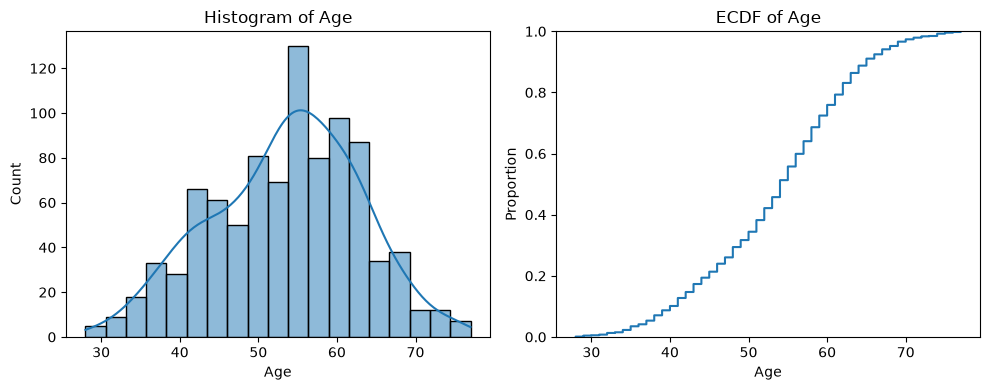

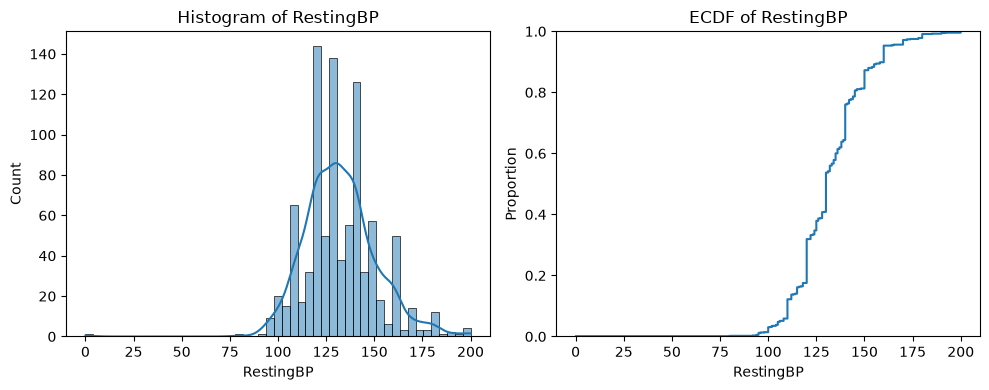

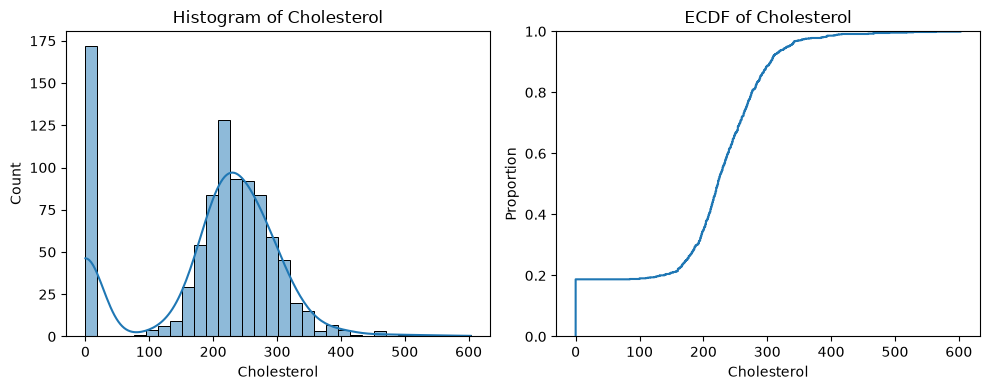

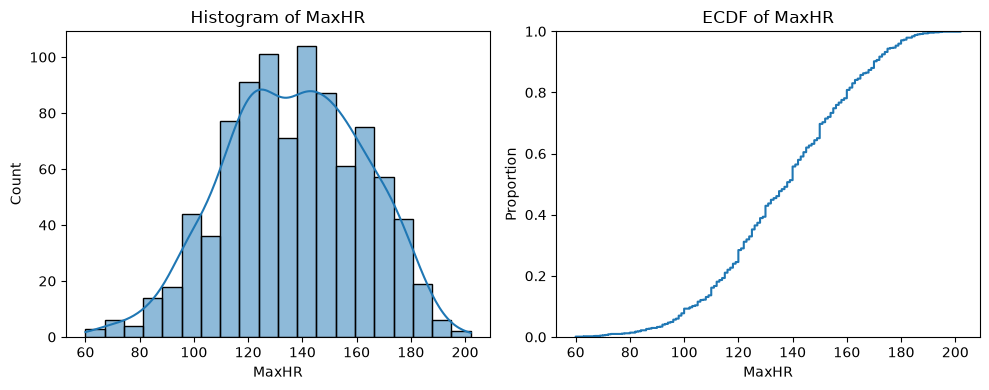

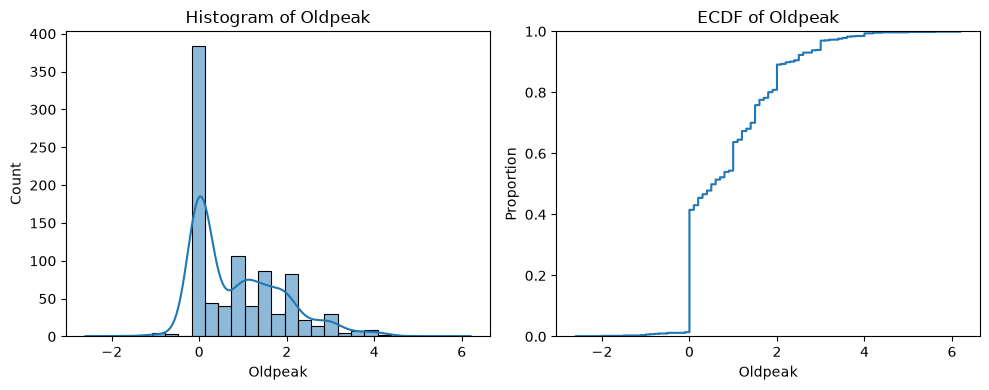

In [27]:
import matplotlib.pyplot as plt

variables = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for var in variables:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(data=bp_df, x=var, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {var}")

    sns.ecdfplot(data=bp_df, x=var, ax=axes[1])
    axes[1].set_title(f"ECDF of {var}")

    plt.tight_layout()
    plt.show()

Age and MaxHR appear roughly bell-shaped, although they are not perfectly normal. RestingBP is concentrated around the middle values but has some extreme observations, including values near zero. Cholesterol has a large number of zero values and is right-skewed, so it does not appear normally distributed. Oldpeak is also right-skewed, with many observations around zero and fewer observations at higher values. Overall, the distributions are not all normal, which makes sense because these variables represent different types of health measurements and patient characteristics.

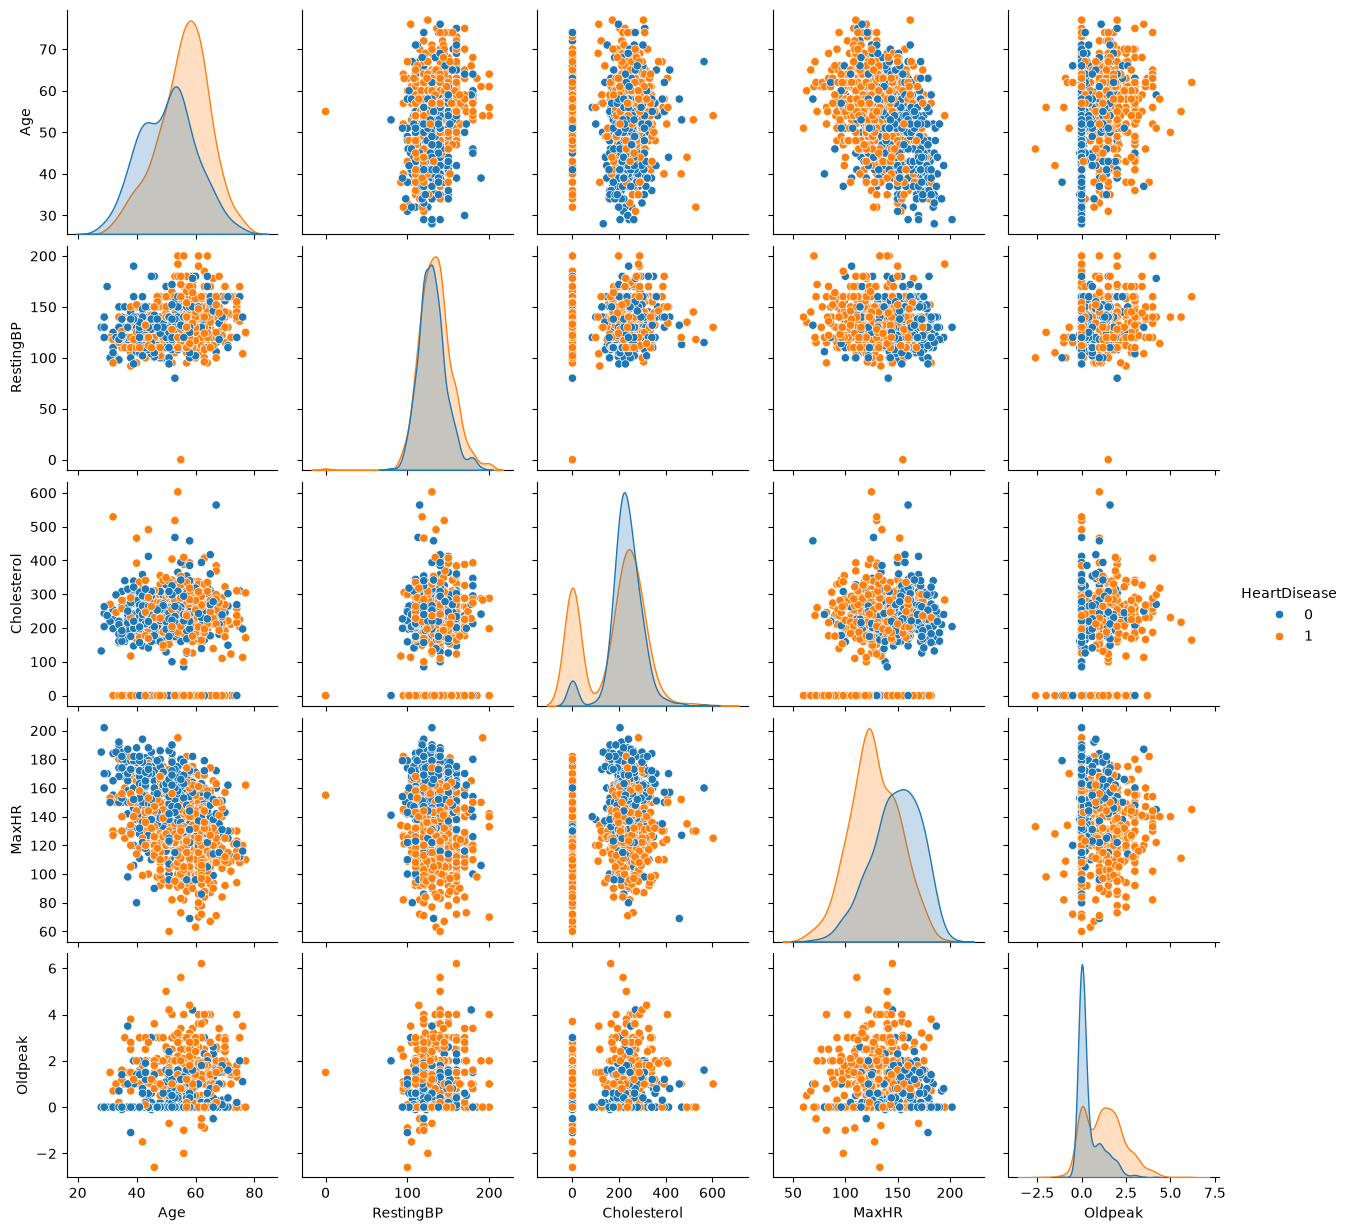

In [28]:
sns.pairplot(
    bp_df,
    vars=["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"],
    hue="HeartDisease"
)

plt.show()

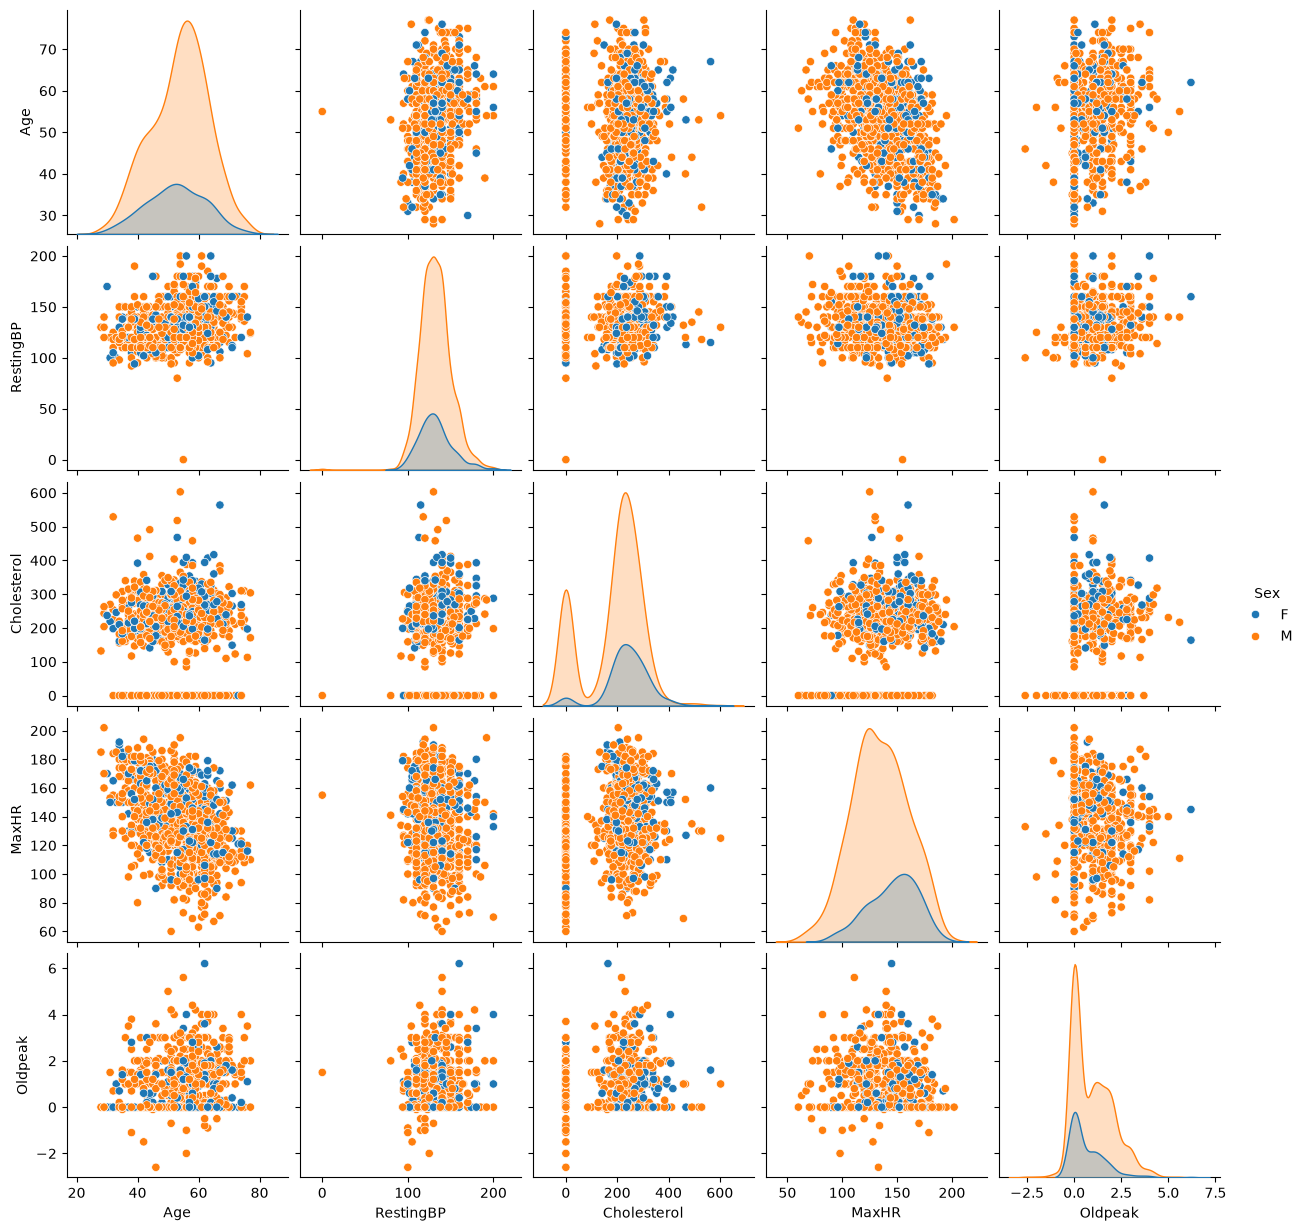

In [29]:
sns.pairplot(
    bp_df,
    vars=["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"],
    hue="Sex"
)

plt.show()

The pairplots show some noticeable patterns in the data. When HeartDisease is used as the hue, people with heart disease generally appear to have lower MaxHR and higher Oldpeak values. Heart disease also appears more frequently among older individuals, although there is still considerable overlap between the two groups. When Sex is used as the hue, males make up a larger portion of the observations, but the distributions of many of the continuous variables overlap between males and females. Overall, MaxHR and Oldpeak seem to show some of the clearest relationships with heart disease compared with the other variables shown.

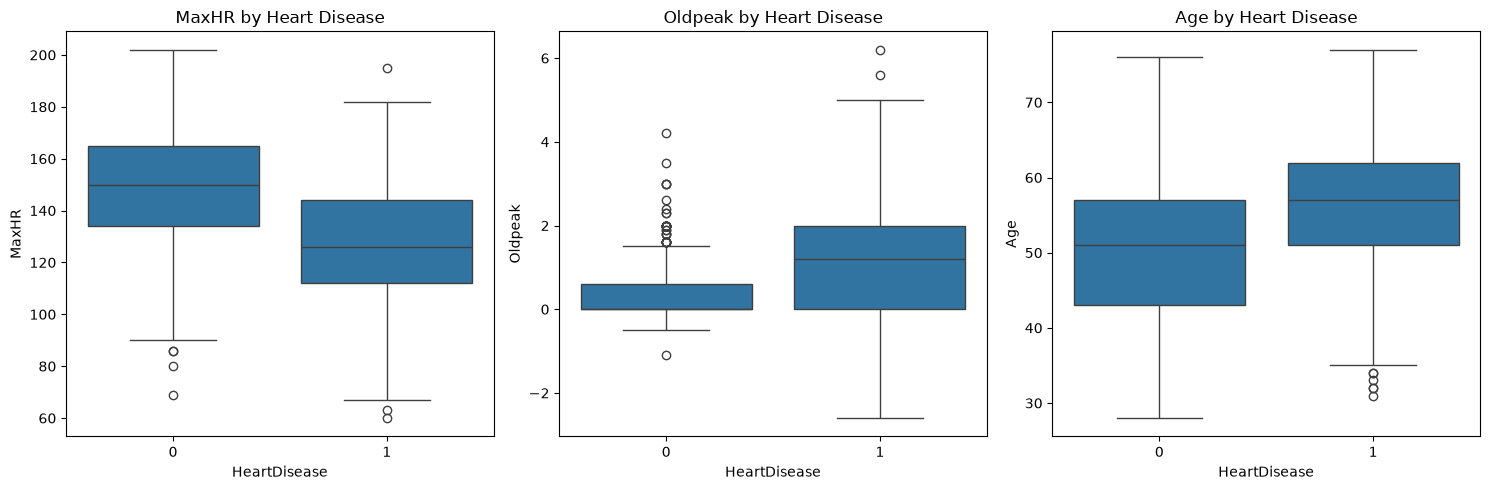

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=bp_df, x="HeartDisease", y="MaxHR", ax=axes[0])
axes[0].set_title("MaxHR by Heart Disease")

sns.boxplot(data=bp_df, x="HeartDisease", y="Oldpeak", ax=axes[1])
axes[1].set_title("Oldpeak by Heart Disease")

sns.boxplot(data=bp_df, x="HeartDisease", y="Age", ax=axes[2])
axes[2].set_title("Age by Heart Disease")

plt.tight_layout()
plt.show()

The boxplots show some clear differences between people with and without heart disease. People with heart disease tend to have a lower maximum heart rate and a higher Oldpeak value. They also tend to be older than people without heart disease. Of the three variables, the difference in MaxHR is especially noticeable because the median is considerably lower for the heart disease group. These results suggest that MaxHR, Oldpeak, and age may all have useful relationships with heart disease in this data set.

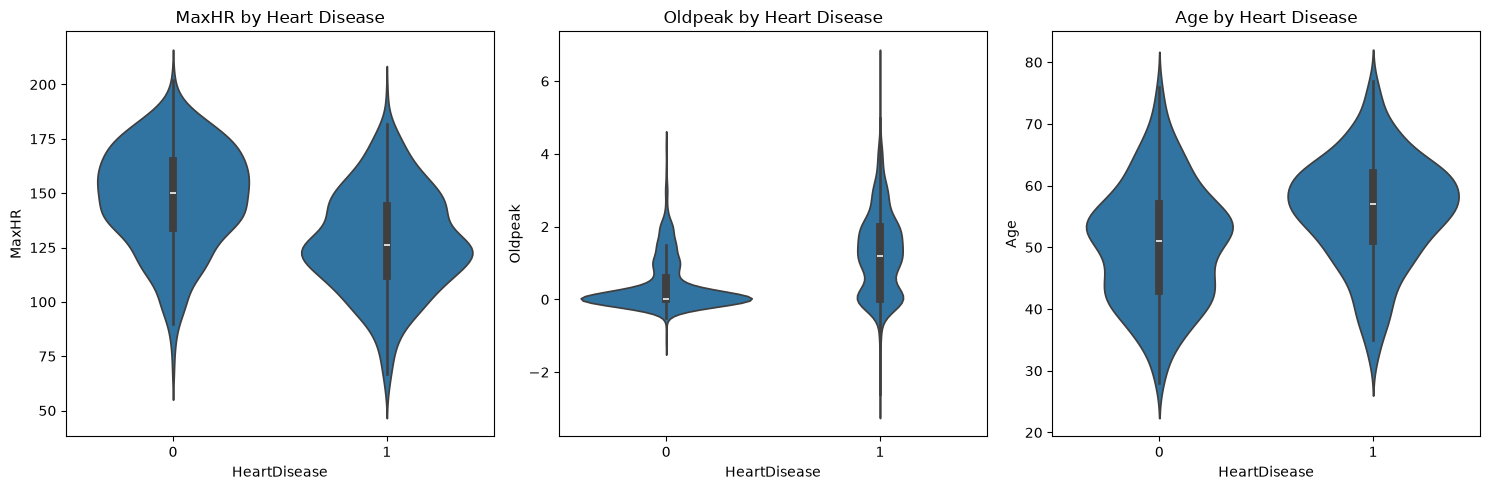

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.violinplot(data=bp_df, x="HeartDisease", y="MaxHR", ax=axes[0])
axes[0].set_title("MaxHR by Heart Disease")

sns.violinplot(data=bp_df, x="HeartDisease", y="Oldpeak", ax=axes[1])
axes[1].set_title("Oldpeak by Heart Disease")

sns.violinplot(data=bp_df, x="HeartDisease", y="Age", ax=axes[2])
axes[2].set_title("Age by Heart Disease")

plt.tight_layout()
plt.show()

In [32]:
maxhr_stats = bp_df["MaxHR"].agg(["mean", "median", "std"])
maxhr_stats

mean      136.809368
median    138.000000
std        25.460334
Name: MaxHR, dtype: float64

In [33]:
maxhr_pivot = bp_df.groupby(
    ["HeartDisease", "Sex"],
    observed=True
)["MaxHR"].agg(["mean", "median", "std"])

maxhr_pivot

mean  median        std
HeartDisease Sex                               
0            F    149.048951   152.0  21.597903
             M    147.670412   150.0  24.170369
1            F    137.820000   142.5  21.820876
             M    126.545852   125.0  23.306611

In [34]:
maxhr_pivot2 = bp_df.groupby(
    ["HeartDisease", "ChestPainType"],
    observed=True
)["MaxHR"].agg(["mean", "median", "std"])

maxhr_pivot2

mean  median        std
HeartDisease ChestPainType                               
0            ASY            138.548077   140.0  24.303054
             ATA            152.255034   154.0  20.748219
             NAP            150.641221   154.0  23.246859
             TA             150.500000   150.0  23.627526
1            ASY            125.806122   125.0  22.548343
             ATA            137.500000   142.0  27.327323
             NAP            129.763889   127.0  24.311646
             TA             144.500000   144.0  22.600652

The pivot tables show a noticeable relationship between maximum heart rate and heart disease. In the table grouped by heart disease and sex, both males and females with heart disease have a lower average MaxHR than those without heart disease. The difference is especially noticeable among males. The table grouped by chest pain type shows a similar pattern, with MaxHR generally being lower for people with heart disease across the different chest pain categories. This suggests that MaxHR may be an important variable associated with heart disease in this data set, although the relationship also varies depending on sex and chest pain type.